# Order Book Signals on Bond & Equity Calendar Spreads

## 1  Setup & Connection

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import polars.selectors as cs
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from plotnine import *
from plotnine.themes import theme_bw

from src.utils import (
    connect_snowflake,
    create_snowpark_session,
    retrieve_polars_from_snowpark,
    unpack_kwargs,
    unpack_kwargs_for_agg,
    read_table,
    parse_security,
    build_contract_calendar,
    add_roll_window,
    add_microstructure_signals,
    acf_by_security,
    ljungbox_by_security,
    newey_west_maxlags,
)
from snowflake.snowpark import functions as F
from snowflake.snowpark.window import Window
from functools import reduce
import operator

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)
print('polars', pl.__version__)

polars 1.41.2


In [2]:
DB     = 'LISTED_INTERN_PROJECT'
SCHEMA = 'PROJECT_5'
TABLES = ['BINNED_DATA', 'QCODE_MAPPING', 'SECURITY_META']

snowflake_conn = connect_snowflake('../.env')
snowpark = create_snowpark_session('../.env')
print('Connected.')

Connected.


## 2  Data Ingestion

Pull only the required columns from each Snowflake table (the projection is pushed down to
Snowflake so we transfer the minimum over the wire). Column names come back lower-cased.

In [3]:
# --- 2  Data Ingestion -------------------------------------------------------------
# Small-scale subset: 2 Phys + 2 Cash qcodes, years 2024-2025.
#
# Futures and calendar spreads of the same product carry DIFFERENT QCODEs in BINNED_DATA,
# so we cannot use a single QCODE filter to capture both instrument types.  Instead:
#   • Futures  — matched by QCODE AND SECURITY NOT LIKE '%/%' (no slash in name).
#   • Spreads  — matched by SECURITY LIKE pattern: {BBG_CODE}%/% {YELLOW_KEY}.
#
# The 2024-2025 date restriction is applied in Section 3 after the contract calendar
# is joined (target_date is delivery-type-aware and not available until that join).
#
# Note: Snowpark's Column.contains() treats its argument as a column identifier, not a
# literal string. All substring checks are expressed as LIKE patterns to avoid this.

BINNED_COLS = [
    'QCODE', 'SECURITY', 'BIN_START_TIME', 'PUBLICATION_DATE',
    'BID_SIZE_START', 'ASK_SIZE_START', 'BID_START', 'ASK_START',
    'VOLUME', 'SIGNED_VOLUME',
]
QCODE_COLS    = ['QCODE', 'BBG_CODE', 'YELLOW_KEY', 'DELIVERY', 'IS_CONVENTION_BUY_NEAR']
SEC_META_COLS = ['SECURITY', 'LAST_TRADE_DATE', 'FIRST_NOTICE_DATE']

qmap     = read_table(snowpark, DB, SCHEMA, 'QCODE_MAPPING', QCODE_COLS)
sec_meta = read_table(snowpark, DB, SCHEMA, 'SECURITY_META', SEC_META_COLS)

# Pick 2 Phys + 2 Cash qcodes for small-scale workshopping.
phys_qcodes = qmap.filter(pl.col('delivery') == 'Phys')['qcode'].unique().to_list()
cash_qcodes = qmap.filter(pl.col('delivery') == 'Cash')['qcode'].unique().to_list()
subset_qcodes = phys_qcodes + cash_qcodes
print(f'Phys qcodes : {phys_qcodes}')
print(f'Cash qcodes : {cash_qcodes}')

# BBG_CODE + YELLOW_KEY for the 4 selected products — used to construct the spread filter.
subset_products = (
    qmap.filter(pl.col('qcode').is_in(subset_qcodes))
    .select('bbg_code', 'yellow_key')
    .unique()
)

fqn_binned = f'{DB}.{SCHEMA}.BINNED_DATA'

# Futures: QCODE in our subset AND SECURITY has no slash (LIKE '%/%' negated).
futures_filter = (
    F.col('QCODE').isin(subset_qcodes) &
    ~F.col('SECURITY').like('%/%')
)

# Spreads: SECURITY matches pattern  {BBG_CODE}.../{...} {YELLOW_KEY}.
# Using Snowflake LIKE: '%' = zero-or-more wildcard characters.

spread_clauses = [
    F.col('SECURITY').like(f'{row["bbg_code"]}%/% {row["yellow_key"]}')
    for row in subset_products.iter_rows(named=True)
]
spread_filter = reduce(operator.or_, spread_clauses)

snow_binned = (
    snowpark.table(fqn_binned)
    .select(*BINNED_COLS)
    .filter(futures_filter | spread_filter)
)
binned = retrieve_polars_from_snowpark(snow_binned)

n_fut = binned.filter(~pl.col('security').str.contains('/')).height
n_spr = binned.filter(pl.col('security').str.contains('/')).height
print(f'binned   : {binned.shape}  (futures: {n_fut:,}  |  spreads: {n_spr:,})')
print(f'qmap     : {qmap.shape}')
print(f'sec_meta : {sec_meta.shape}')
binned.head()

Phys qcodes : ['TU', 'GH', 'GX', 'GM', 'FV', 'BF', 'IE', 'IL']
Cash qcodes : ['ES', 'DF', 'FX', 'SV', 'AZ', 'OX', 'TT', 'NN', 'PI', 'HN']
binned   : (13901208, 10)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)


qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume
str,str,time,date,f64,f64,f64,f64,i32,i32
"""OX""","""QC2022M/2022N Index""",09:55:00,2022-06-14,2569.0,459.0,0.0,0.05,615,-1
"""DF""","""GX2022M Index""",12:00:00,2022-04-14,2.0,2.0,14093.0,14095.0,434,32
"""PI""","""XP2022H/2022M Index""",10:45:00,2022-01-11,6.0,6.0,17.0,53.0,0,0
"""HN""","""XU2022H Index""",15:00:00,2022-03-10,5.0,4.0,13742.0,13744.0,2611,-249
"""NN""","""NQ2023Z Index""",11:35:00,2023-12-08,3.0,1.0,16049.75,16050.25,2781,294


## 3  Merge, Parse Tickers, Build the Contract Calendar & Filter to 2024-2025

**Step 1** — merge `BINNED_DATA` with `QCODE_MAPPING` on `QCODE`. Spreads pulled via name
pattern may carry a QCODE outside the futures subset; their qmap columns are left as null and
the authoritative `delivery` comes from the calendar (Step 3).

**Step 2** — parse the `SECURITY` string to flag futures vs. calendar spreads and, for every
spread, construct the explicit **near** and **far** single-future tickers. Each row also gets a
`meta_key`: the near leg for spreads (since `SECURITY_META` has no spread rows), the contract
itself for futures.

**Step 3 & 4** — build a per-future roll calendar from `SECURITY_META`: pick the target date
(`LAST_TRADE_DATE` for `Cash`, `FIRST_NOTICE_DATE` for `Phys`), compute each contract's own
10-business-day roll window, and attach the *previous* chronological contract's window. Join the
calendar onto the data via `meta_key`. The qmap's `delivery` column (null for spreads) is dropped
before this join so the calendar's `delivery` (always resolved from BBG_CODE + YELLOW_KEY) is used.

**Step 5** — derive the trading `date` from `PUBLICATION_DATE` (`BIN_START_TIME` is time-only).

**Step 6** — keep only rows whose near-leg `target_date` falls in **2024 or 2025**. This is the
date-range restriction for the workshop subset.

In [48]:
# --- 3  Merge + parse + calendar + date filter ------------------------------------

# Step 1: merge BINNED_DATA with QCODE_MAPPING on QCODE.
# Spreads pulled via the name-pattern filter may have QCODEs outside subset_qcodes,
# so their bbg_code / yellow_key / delivery / is_convention_buy_near will be null here.
data = binned.join(qmap, on='qcode', how='left')

# Step 2: parse SECURITY -> is_spread, near/far identifiers, meta_key.
data = parse_security(data, col='security')

data.head()

# Steps 3-4: build the per-future roll calendar (target date + own/previous roll windows).
calendar = build_contract_calendar(sec_meta, qmap, roll_days=10)

# Drop qmap's 'delivery' before joining the calendar so the calendar's 'delivery'
# (correctly resolved from BBG_CODE+YELLOW_KEY for every security) is the sole authority.
data = data.drop('delivery')
data = data.join(
    calendar.rename({'security': 'meta_key'}),
    on='meta_key',
    how='left',
)

# Step 5: trading date from PUBLICATION_DATE (BIN_START_TIME is time-only, not a date).
data = data.with_columns(date=pl.col('publication_date').cast(pl.Date))

# Step 6: keep only rows whose near-leg target date is in 2024 or 2025.
# target_date = FIRST_NOTICE_DATE (Phys) or LAST_TRADE_DATE (Cash), already set by the calendar.
data = data.filter(pl.col('publication_date').dt.year().is_in([2024, 2025]))

n_spread = data.filter(pl.col('is_spread')).height
print(f'rows: {data.height:,}  |  spread rows: {n_spread:,}  |  future rows: {data.height - n_spread:,}')
data.select(
    'security', 'is_spread', 'near_identifier', 'far_identifier', 'meta_key',
    'delivery', 'target_date', 'roll_start', 'roll_end', 'prev_roll_start', 'prev_roll_end',
).head()

rows: 2,712,379  |  spread rows: 888,043  |  future rows: 1,824,336


security,is_spread,near_identifier,far_identifier,meta_key,delivery,target_date,roll_start,roll_end,prev_roll_start,prev_roll_end
str,bool,str,str,str,str,date,date,date,date,date
"""RX2024U Comdty""",false,"""RX2024U Comdty""",null,"""RX2024U Comdty""","""Phys""",2024-09-06,2024-08-23,2024-09-05,2024-05-23,2024-06-05
"""TP2024M Index""",false,"""TP2024M Index""",null,"""TP2024M Index""","""Cash""",2024-06-13,2024-05-30,2024-06-12,2024-02-22,2024-03-06
"""VG2024H Index""",false,"""VG2024H Index""",null,"""VG2024H Index""","""Cash""",2024-03-15,2024-03-01,2024-03-14,2023-12-01,2023-12-14
"""QZ2024U Index""",false,"""QZ2024U Index""",null,"""QZ2024U Index""","""Cash""",2024-09-27,2024-09-13,2024-09-26,2024-08-15,2024-08-28
"""IK2024M Comdty""",false,"""IK2024M Comdty""",null,"""IK2024M Comdty""","""Phys""",2024-06-06,2024-05-23,2024-06-05,2024-02-22,2024-03-06


## 4  Roll-Period Filtering → `df_cs` & `df_combined`

**Step 7** — keep only rows whose `date` (from `PUBLICATION_DATE`) falls inside the relevant
roll window:

- **Calendar spreads** — inside their *own* roll period (their near leg's window).
- **Futures** — inside *either* their own roll period *or* their immediately-previous
  chronological contract's roll period.

Outputs:
- `df_cs` — filtered calendar spreads only.
- `df_combined` — filtered calendar spreads **and** filtered futures.

In [49]:
# --- 5  Roll-period filtering -----------------------------------------------------

# A bin sits inside a [start, end] window (inclusive). Null bounds (missing metadata) -> False.
def _in_window(start: str, end: str) -> pl.Expr:
    return pl.col('date').is_between(pl.col(start), pl.col(end), closed='both').fill_null(False)

in_own_roll  = _in_window('roll_start', 'roll_end')
in_prev_roll = _in_window('prev_roll_start', 'prev_roll_end')

# Calendar spreads: own (near-leg) roll period only.
df_cs = data.filter(pl.col('is_spread') & in_own_roll)

# Futures: own roll period OR previous contract's roll period.
df_fut = data.filter(~pl.col('is_spread') & (in_own_roll | in_prev_roll))

# Combined: filtered spreads + filtered futures (aligned schema via vertical concat).
df_combined = pl.concat([df_cs, df_fut], how='vertical')

print(f'df_cs       : {df_cs.shape}')
print(f'df_fut      : {df_fut.shape}')
print(f'df_combined : {df_combined.shape}')
df_cs.head()

df_cs       : (203581, 27)
df_fut      : (407469, 27)
df_combined : (611050, 27)


qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,bbg_code,yellow_key,is_convention_buy_near,is_spread,near_identifier,far_identifier,near_expiry_key,far_expiry_key,meta_key,expiry_key,delivery,target_date,roll_start,roll_end,prev_roll_start,prev_roll_end,date
str,str,time,date,f64,f64,f64,f64,i32,i32,str,str,f64,bool,str,str,i32,i32,str,i32,str,date,date,date,date,date,date
"""OX""","""QC2024F/2024G Index""",12:05:00,2024-01-08,25.0,10.0,6.25,6.65,0,0,"""QC""","""Index""",0.0,true,"""QC2024F Index""","""QC2024G Index""",202401,202402,"""QC2024F Index""",202401,"""Cash""",2024-01-19,2024-01-05,2024-01-18,2023-12-01,2023-12-14,2024-01-08
"""OX""","""QC2024F/2024G Index""",12:20:00,2024-01-08,25.0,10.0,6.25,6.65,1,1,"""QC""","""Index""",0.0,true,"""QC2024F Index""","""QC2024G Index""",202401,202402,"""QC2024F Index""",202401,"""Cash""",2024-01-19,2024-01-05,2024-01-18,2023-12-01,2023-12-14,2024-01-08
"""OX""","""QC2024F/2024G Index""",16:00:00,2024-01-08,25.0,54.0,6.35,6.7,2,2,"""QC""","""Index""",0.0,true,"""QC2024F Index""","""QC2024G Index""",202401,202402,"""QC2024F Index""",202401,"""Cash""",2024-01-19,2024-01-05,2024-01-18,2023-12-01,2023-12-14,2024-01-08
"""AZ""","""EO2024G/2024H Index""",16:05:00,2024-02-12,1061.0,3949.0,-1.7,-1.65,3,3,"""EO""","""Index""",1.0,true,"""EO2024G Index""","""EO2024H Index""",202402,202403,"""EO2024G Index""",202402,"""Cash""",2024-02-16,2024-02-02,2024-02-15,2024-01-05,2024-01-18,2024-02-12
"""AZ""","""EO2024X/2024Z Index""",17:30:00,2024-11-07,401.0,684.0,-3.05,-3.0,0,0,"""EO""","""Index""",1.0,true,"""EO2024X Index""","""EO2024Z Index""",202411,202412,"""EO2024X Index""",202411,"""Cash""",2024-11-15,2024-11-01,2024-11-14,2024-10-04,2024-10-17,2024-11-07


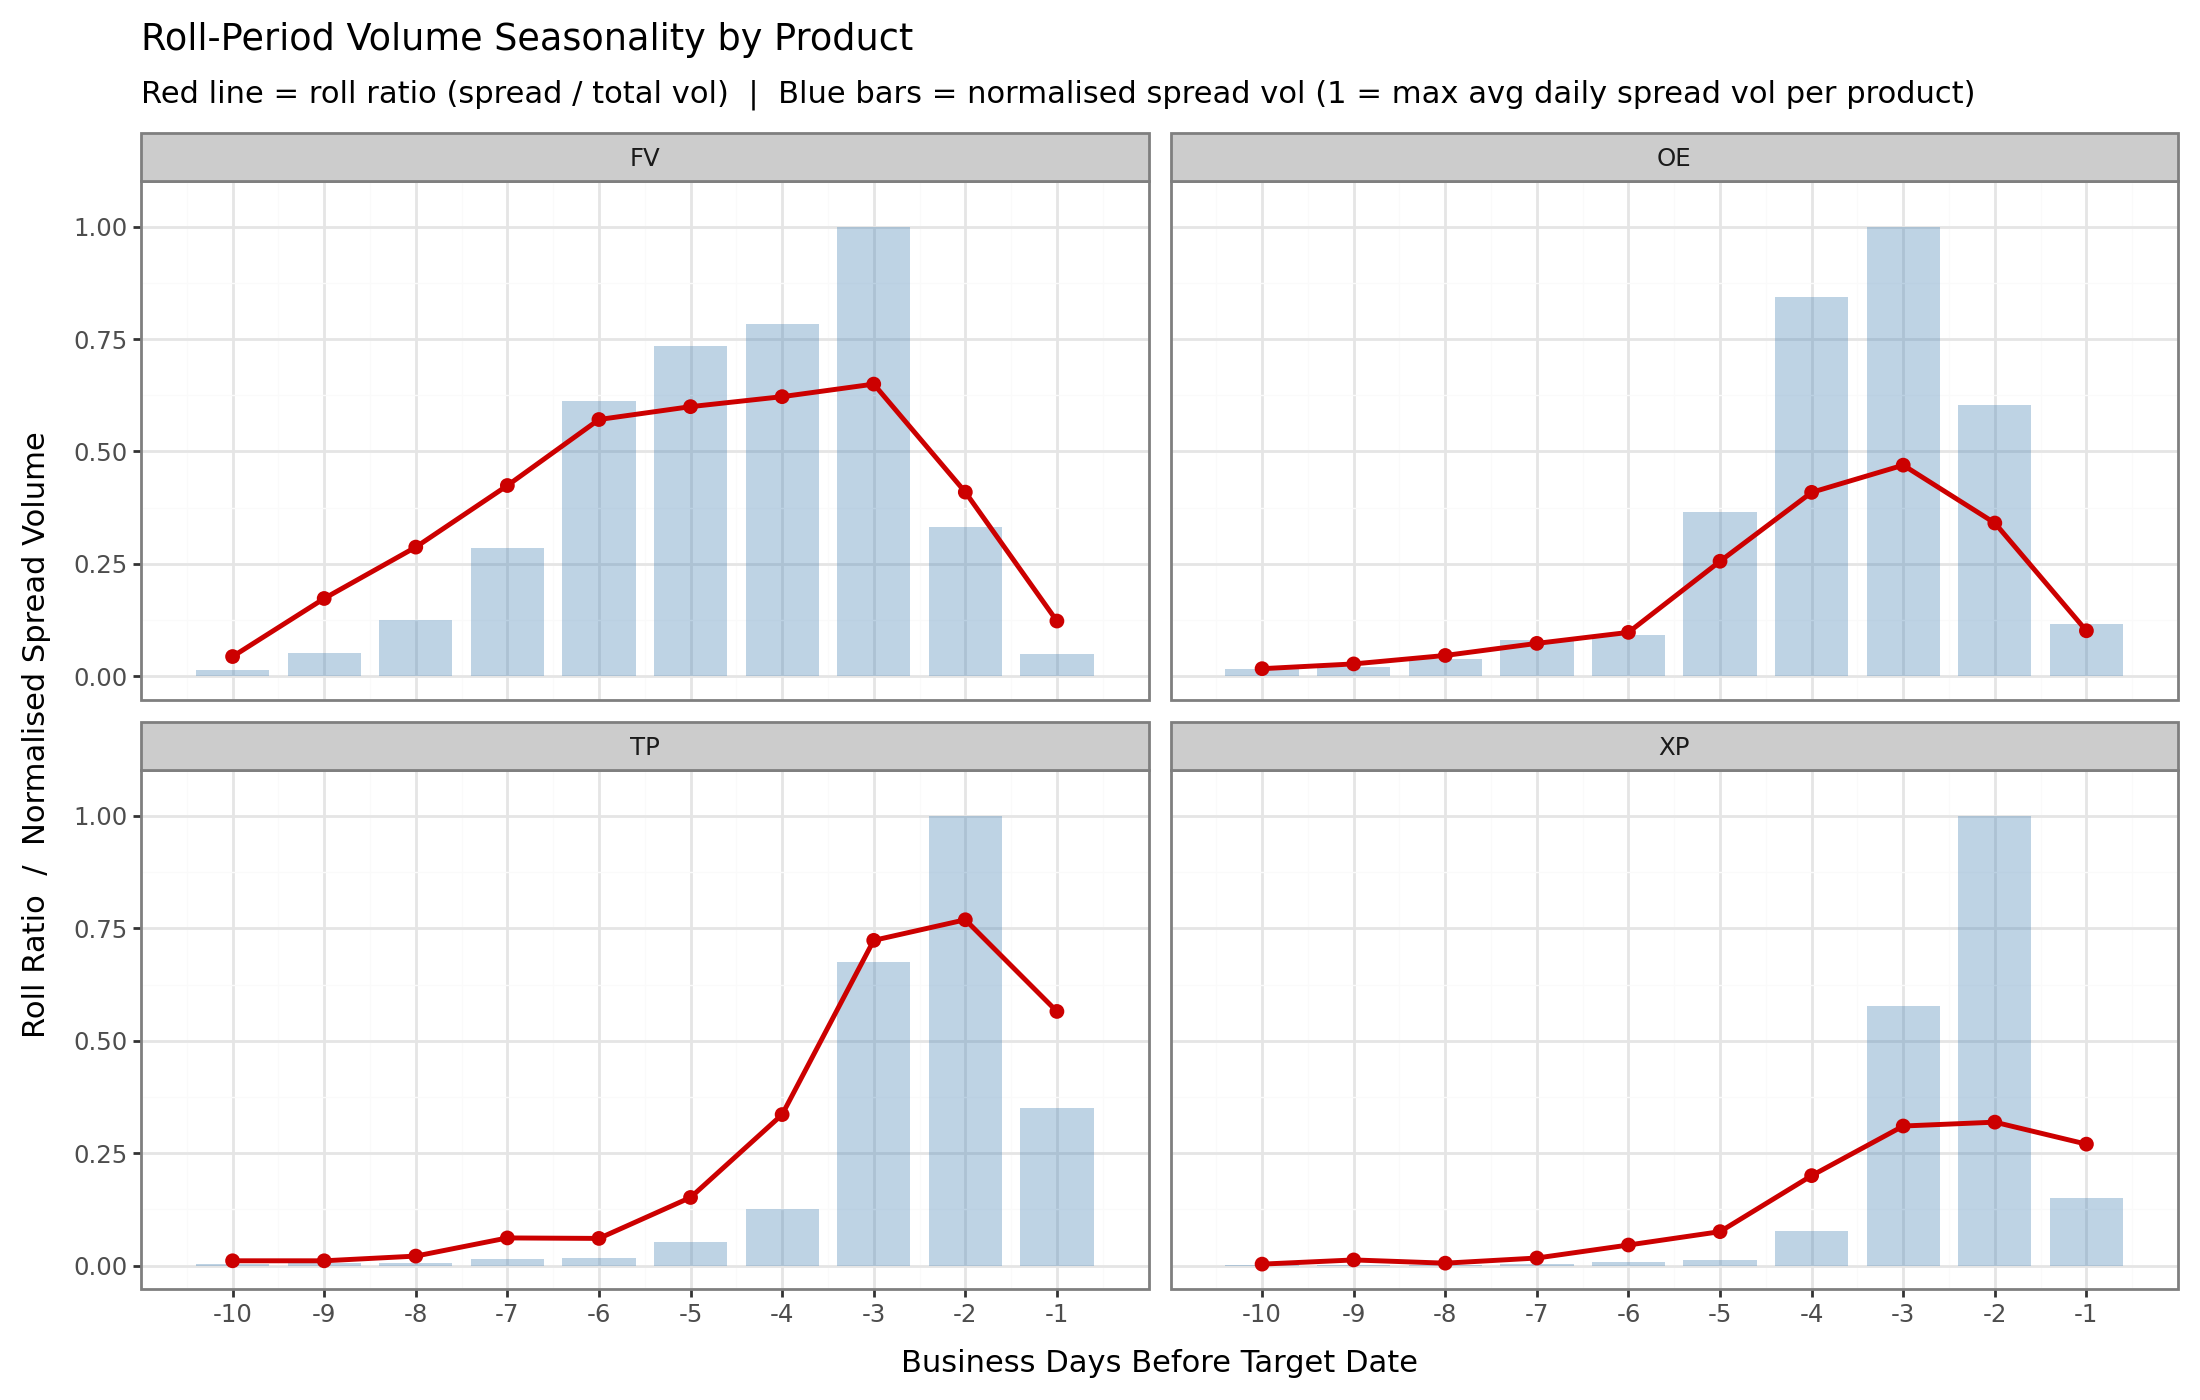

In [40]:
# --- 4b  Roll-Period Seasonality: Volume Dynamics ---------------------------------
# For each BBG_CODE, compute daily volumes for the spread, its near-leg outright,
# and its far-leg outright.  The x-axis is business days before the target date
# (= first notice date for Phys, last trade date for Cash), running from -10 to -1.
# Roll ratio = spread vol / (spread + near + far).
# Each panel shows roll ratio as a line and normalised spread volume as background bars.

# Daily spread volumes
spread_daily = (
    df_cs
    .filter(pl.col('bbg_code').is_not_null() & pl.col('target_date').is_not_null())
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_spread=pl.col('volume').cast(pl.Float64).sum())
)

# For each (bbg_code, date), the spread tells us which near and far futures are
# active in the same roll event; use that to look up outright volumes in df_combined.
legs_ref = (
    df_cs
    .filter(pl.col('bbg_code').is_not_null() & pl.col('target_date').is_not_null())
    .select(['bbg_code', 'date', 'near_identifier', 'far_identifier', 'target_date'])
    .unique()
)
fut_pool = (
    df_combined.filter(~pl.col('is_spread'))
    .select(['bbg_code', 'date', 'security', 'volume'])
)

near_daily = (
    fut_pool
    .join(
        legs_ref.select(['bbg_code', 'date', 'near_identifier', 'target_date'])
                .rename({'near_identifier': 'security'}),
        on=['bbg_code', 'date', 'security'], how='inner',
    )
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_near=pl.col('volume').cast(pl.Float64).sum())
)

far_daily = (
    fut_pool
    .join(
        legs_ref.select(['bbg_code', 'date', 'far_identifier', 'target_date'])
                .rename({'far_identifier': 'security'}),
        on=['bbg_code', 'date', 'security'], how='inner',
    )
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_far=pl.col('volume').cast(pl.Float64).sum())
)

# Combine and compute business-day distance to target
vol_df = (
    spread_daily
    .join(near_daily, on=['bbg_code', 'date', 'target_date'], how='left')
    .join(far_daily,  on=['bbg_code', 'date', 'target_date'], how='left')
    .fill_null(0.0)
)

# np.busday_count(start, end) = business days from start to end (positive).
# Negate so that 1 business day before target = -1.
_dates   = vol_df['date'].to_numpy().astype('datetime64[D]')
_targets = vol_df['target_date'].to_numpy().astype('datetime64[D]')
vol_df   = vol_df.with_columns(
    days_before=pl.Series(-np.busday_count(_dates, _targets))
)

# Roll ratio; aggregate across all roll events per (bbg_code, days_before)
vol_df = (
    vol_df
    .filter(pl.col('days_before').is_between(-10, -1))
    .with_columns(
        roll_ratio=pl.col('vol_spread') /
            (pl.col('vol_spread') + pl.col('vol_near') + pl.col('vol_far'))
    )
)

plot_df = (
    vol_df
    .group_by(['bbg_code', 'days_before'])
    .agg(
        roll_ratio=pl.col('roll_ratio').mean(),
        vol_spread=pl.col('vol_spread').mean(),
    )
    .sort(['bbg_code', 'days_before'])
)

# Normalise spread volume to [0, 1] within each BBG_CODE so bars share the y-axis
# with roll ratio (bar height 1 = max avg daily spread volume for that product).
_vmax = plot_df.group_by('bbg_code').agg(_vmax=pl.col('vol_spread').max())
plot_df = (
    plot_df
    .join(_vmax, on='bbg_code', how='left')
    .with_columns(vol_spread_norm=(pl.col('vol_spread') / pl.col('_vmax')).fill_nan(0.0))
    .drop('_vmax')
    .to_pandas()
)

(
    ggplot(plot_df, aes(x='days_before')) +
    geom_col(aes(y='vol_spread_norm'), fill='steelblue', alpha=0.35, width=0.8) +
    geom_line(aes(y='roll_ratio'), color='#CC0000', size=1.0) +
    geom_point(aes(y='roll_ratio'), color='#CC0000', size=2.0) +
    scale_x_continuous(
        breaks=list(range(-10, 0)),
        limits=(-10.5, -0.5),
    ) +
    scale_y_continuous(
        limits=(0, 1.05),
        breaks=[0, 0.25, 0.5, 0.75, 1.0],
    ) +
    facet_wrap('~bbg_code', nrow=2) +
    labs(
        title='Roll-Period Volume Seasonality by Product',
        subtitle=(
            'Red line = roll ratio (spread / total vol)  |  '
            'Blue bars = normalised spread vol (1 = max avg daily spread vol per product)'
        ),
        x='Business Days Before Target Date',
        y='Roll Ratio  /  Normalised Spread Volume',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(11, 7))
)


## 5  Microstructure Signal Generation (Research Plan §3)

Compute the order-book / flow signals on the filtered calendar-spread set `df_cs`. **CRITICAL —
strictly intraday:** all lag-dependent quantities are partitioned by the trading **session
`[SECURITY, DATE]`** (not just the contract) and ordered by `BIN_START_TIME`, so a lag never
spans an overnight gap, a weekend, or a day boundary. The first bin of each session has null
lags and is dropped. Using the per-bin `*_START` quotes:

| Signal | Definition |
|---|---|
| $P_t$ (`mid_price`) | $(\text{BID\_START} + \text{ASK\_START})/2$ |
| $\Delta P_t$ (`delta_p`) | $P_t - P_{t-1}$ (within session) |
| $OBI_t$ (`obi`) | $\text{BID\_SIZE\_START} - \text{ASK\_SIZE\_START}$ |
| $\Delta L_t^b$ (`delta_lb`) | $Q_t^b-Q_{t-1}^b$ if $P_t^b=P_{t-1}^b$; $\;Q_t^b$ if $P_t^b>P_{t-1}^b$; $\;-Q_{t-1}^b$ if $P_t^b<P_{t-1}^b$ |
| $\Delta L_t^a$ (`delta_la`) | mirror of the bid (an ask *improvement* is a price **decrease**) |
| $OBC_t$ (`ofi`) | $\Delta L_t^b - \Delta L_t^a$  (order-flow imbalance) |
| $STV_t$ (`stv`) | `SIGNED_VOLUME` (dataset); empty bins → 0 |
| $NOI_t$ (`noi`) | $OBC_t - STV_t$ |

A `date` session key is added automatically. Result is saved to **`df_signals`**.

In [50]:
# --- 5  Signal generation (partitioned by SESSION [security, date], ordered by time) ----
df_signals = add_microstructure_signals(df_cs, security_col='security', time_col='bin_start_time')

n_sessions = df_signals.select(['security', 'date']).n_unique()
print(f'df_signals: {df_signals.shape}  ({df_signals["security"].n_unique()} spreads, {n_sessions} sessions)')
df_signals.select(
    'security', 'date', 'bin_start_time', 'mid_price', 'delta_p', 'obi',
    'delta_lb', 'delta_la', 'ofi', 'stv', 'noi', 'days_before'
).describe()

df_signals: (201507, 36)  (208 spreads, 2074 sessions)


statistic,security,date,bin_start_time,mid_price,delta_p,obi,delta_lb,delta_la,ofi,stv,noi,days_before
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""201507""","""201507""","""201507""",201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2025-01-09 13:47:02.319820""","""12:48:41.037978""",-1.374796,0.005264,2590.718437,-348.551693,922.855077,-1271.40677,-35.882232,-1235.524538,5.488995
"""std""",null,null,null,61.790512,1.15069,466630.043527,113731.309124,102309.3558,175715.280882,6379.900855,175507.260702,2.870565
"""min""","""DU2024H/2024M Comdty""","""2024-01-05""","""07:05:00""",-296.75,-63.0,-8.572536e6,-7.166885e6,-5.647385e6,-1.3020008e7,-730759.0,-1.2936424e7,1.0
"""25%""",null,"""2024-07-05""","""10:45:00""",-1.635,0.0,-568.0,-25.0,-34.0,-40.0,-8.0,-73.0,3.0
"""50%""",null,"""2025-01-03""","""12:45:00""",-0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
"""75%""",null,"""2025-07-04""","""14:45:00""",1.035,0.0,555.0,10.0,8.0,56.0,17.0,65.0,8.0
"""max""","""XU2025Z/2026F Index""","""2025-12-29""","""18:00:00""",305.725,442.0,8.222161e6,6.225243e6,5.853123e6,9.340875e6,449539.0,9.339053e6,10.0


In [51]:
# --- 5b  Normalise signals --------------------------------------------------------
# Normalised values overwrite the raw columns so downstream sections (H1, H2, H3)
# use normalised signals automatically.
#
# All five expressions are evaluated against the INPUT state of df_signals in the
# final with_columns call — Polars never sees intermediate results within the same
# call.  This means pl.col('ofi') in the NOI denominator is the PRE-Z-SCORE raw OFI.
#
# fill_nan(None) converts floating-point 0/0 = NaN to null for inactive bins rather
# than propagating NaN into the regression.

ROLL_WIN = 60   # rolling-window length for OFI z-score (bins, within each session)
SESSION  = ['security', 'date']

# 1. Tick size per BBG_CODE: minimum strictly-positive |delta_p|.
tick_sizes = (
    df_signals
    .filter(pl.col('delta_p').abs() > 10e-6)  # filter out zero and near-zero price changes to avoid noise/tick size confusion)
    .group_by('bbg_code')
    .agg(_tick=pl.col('delta_p').abs().min())
)
df_signals = df_signals.join(tick_sizes, on='bbg_code', how='left')

# Pre-compute rolling OFI mean and std within each session.
# df_signals is already sorted by [security, date, bin_start_time].
df_signals = df_signals.with_columns(
    _ofi_mu=pl.col('ofi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _ofi_sd=pl.col('ofi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)

# Apply all five normalisations in a single pass.
_vol = pl.col('volume').cast(pl.Float64)

df_signals = df_signals.with_columns(
    # 1. delta_p in ticks (per-BBG_CODE tick size).
    delta_p=(pl.col('delta_p') / pl.col('_tick')).fill_nan(None),
    # 2. OBI as fraction of total quoted size at the touch.
    obi=(pl.col('obi') / (pl.col('bid_size_start') + pl.col('ask_size_start'))).fill_nan(None),
    # 3. STV as fraction of unsigned volume.
    stv=(pl.col('stv').cast(pl.Float64).abs().sqrt() * pl.col('stv').sign()).fill_nan(None),
    # 4. OFI as rolling z-score within session.
    ofi=((pl.col('ofi') - pl.col('_ofi_mu')) / pl.col('_ofi_sd')).fill_nan(None),
    # 5. NOI normalised by (unsigned volume + raw |OFI|).
    #    pl.col('ofi') below reads the ORIGINAL raw OFI (input state of this with_columns).
    noi=(pl.col('noi').cast(pl.Float64).abs().sqrt() * pl.col('noi').sign()).fill_nan(None),
).drop(['_ofi_mu', '_ofi_sd'])

print(f'df_signals (normalised): {df_signals.shape}')
df_signals.select('security', 'date', 'bin_start_time', 'delta_p', 'obi', 'stv', 'ofi', 'noi').describe()

df_signals (normalised): (201507, 37)


statistic,security,date,bin_start_time,delta_p,obi,stv,ofi,noi
str,str,str,str,f64,f64,f64,f64,f64
"""count""","""201507""","""201507""","""201507""",201507.0,201507.0,201507.0,197575.0,201507.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,3932.0,0.0
"""mean""",null,"""2025-01-09 13:47:02.319820""","""12:48:41.037978""",0.002923,-0.003161,0.20212,0.007553,-0.650249
"""std""",null,null,null,3.925065,0.539295,27.451221,0.951701,121.054648
"""min""","""DU2024H/2024M Comdty""","""2024-01-05""","""07:05:00""",-126.0,-0.999984,-854.84443,-7.616867,-3596.724065
"""25%""",null,"""2024-07-05""","""10:45:00""",0.0,-0.394366,-2.828427,-0.228955,-8.544004
"""50%""",null,"""2025-01-03""","""12:45:00""",0.0,0.0,0.0,0.006946,0.0
"""75%""",null,"""2025-07-04""","""14:45:00""",0.0,0.386861,4.123106,0.244079,8.062258
"""max""","""XU2025Z/2026F Index""","""2025-12-29""","""18:00:00""",884.0,0.999981,670.476696,7.616867,3055.98642


In [84]:
zero_pct = (df_signals
    .filter((pl.col("days_before") <= 5) & (pl.col("days_before") >= 2))
    .group_by("bbg_code")
    .agg((
        (pl.col("delta_p").abs().cast(pl.Int32) <= 2) &
        (pl.col("delta_p").abs().cast(pl.Int32) != 5)).mean() * 100
    )
    .sort('delta_p')
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
)
spread_one_tick_pct = (df_signals
    .with_columns(is_one_tick=(pl.col("ask_start") - pl.col("bid_start"))//pl.col("_tick") == 2)
    .group_by("bbg_code")
    .agg((pl.col("is_one_tick").mean() * 100))
    .sort('is_one_tick')
    .join(
        qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left'
    )
)
print(f"Percentage of zeros: {zero_pct}%")
print(f"Percentage of one-tick spreads: {spread_one_tick_pct}%")

Percentage of zeros: shape: (18, 3)
┌──────────┬───────────┬────────────┐
│ bbg_code ┆ delta_p   ┆ yellow_key │
│ ---      ┆ ---       ┆ ---        │
│ str      ┆ f64       ┆ str        │
╞══════════╪═══════════╪════════════╡
│ NQ       ┆ 17.267628 ┆ Index      │
│ ES       ┆ 61.538462 ┆ Index      │
│ QC       ┆ 93.172442 ┆ Index      │
│ GX       ┆ 95.006127 ┆ Index      │
│ XU       ┆ 95.078502 ┆ Index      │
│ TP       ┆ 98.572531 ┆ Index      │
│ XP       ┆ 99.547697 ┆ Index      │
│ OAT      ┆ 99.682203 ┆ Comdty     │
│ VG       ┆ 99.732143 ┆ Index      │
│ UB       ┆ 99.814619 ┆ Comdty     │
│ IK       ┆ 99.817708 ┆ Comdty     │
│ DU       ┆ 99.841102 ┆ Comdty     │
│ RX       ┆ 99.947034 ┆ Comdty     │
│ OE       ┆ 99.947034 ┆ Comdty     │
│ EO       ┆ 99.95915  ┆ Index      │
│ QZ       ┆ 99.967448 ┆ Index      │
│ TU       ┆ 99.967784 ┆ Comdty     │
│ FV       ┆ 100.0     ┆ Comdty     │
└──────────┴───────────┴────────────┘%
Percentage of one-tick spreads: shape: (18, 3)
┌───

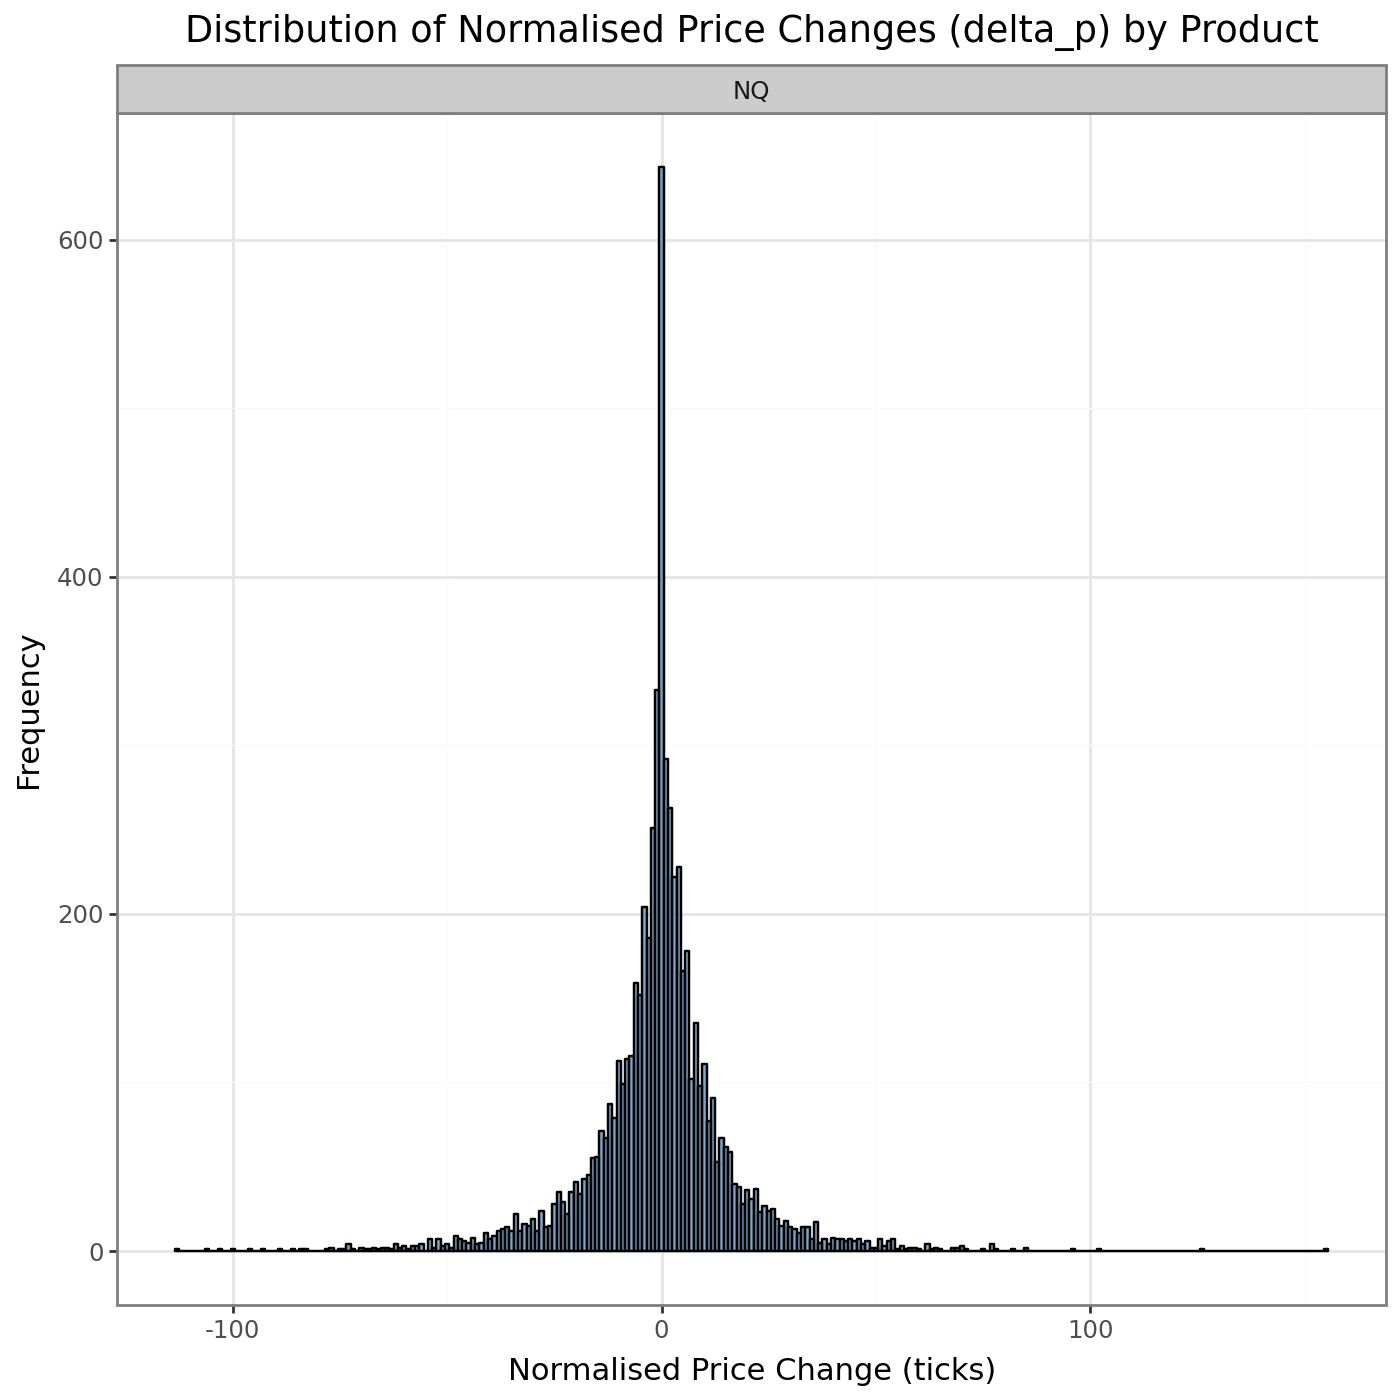

In [95]:
# graph of marginal distribution of delta_p for NQ and OAT
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["NQ"])), aes(x='delta_p')) +
    geom_histogram(binwidth=1, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Price Changes (delta_p) by Product',
        x='Normalised Price Change (ticks)',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

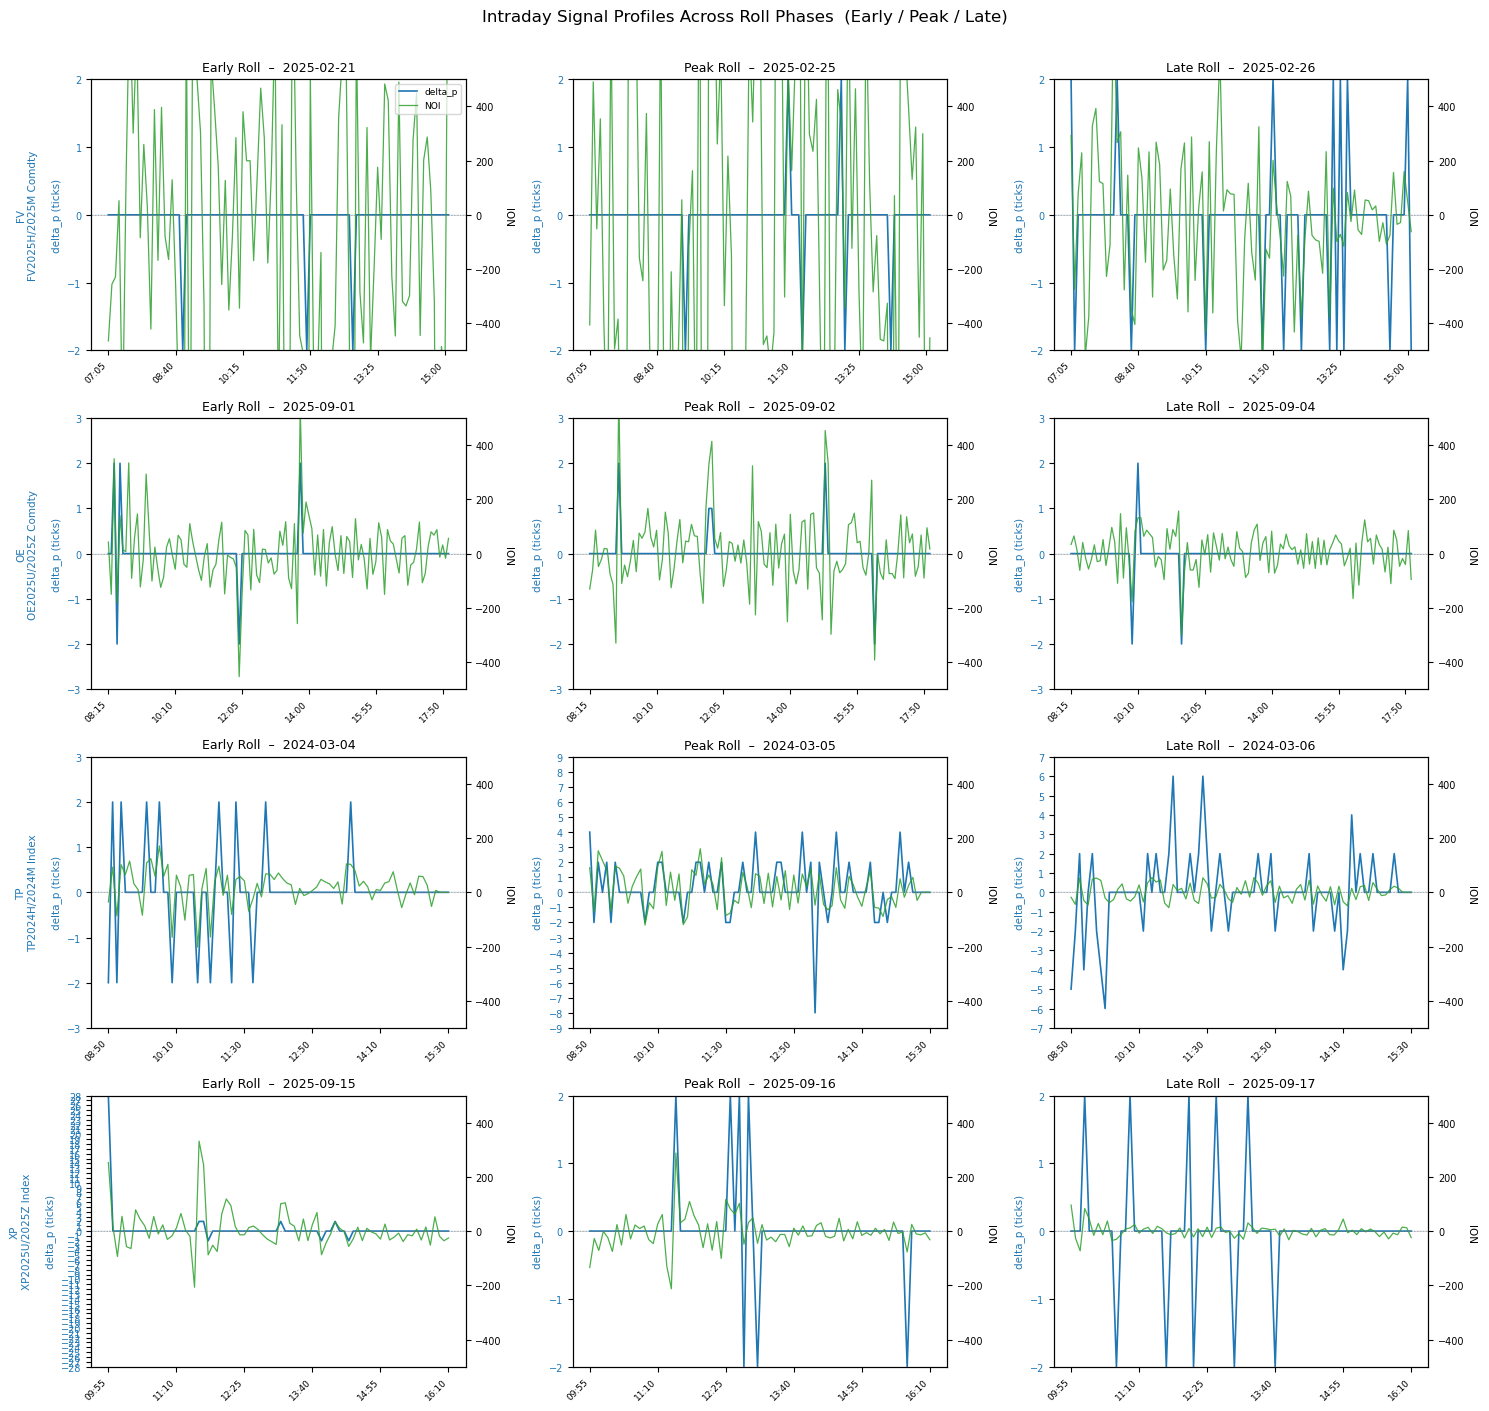

In [105]:
# --- 5c  Intraday Signal Profiles: Early / Peak / Late Roll Days ------------------
# For each BBG_CODE, select the calendar spread security with the highest total
# volume over its roll period, then identify three representative days:
#   Peak  = date with maximum daily spread volume
#   Early = first date with volume >= 25% of peak  (1 business day before peak if tied)
#   Late  = last  date with volume >= 25% of peak  (1 business day after  peak if tied)
# Plot delta_p (left axis) and OBI / NOI / STV (right axis, [-1,1]) vs intraday time.
# Layout: 4 rows (BBG_CODE) x 3 columns (Early / Peak / Late) = 12 plots.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Select one security per BBG_CODE: the one with highest total volume
best_sec_df = (
    df_signals
    .filter(pl.col('bbg_code').is_not_null())
    .group_by(['bbg_code', 'security'])
    .agg(total_vol=pl.col('volume').cast(pl.Float64).sum())
    .sort(['bbg_code', 'total_vol'], descending=[False, True])
    .unique(subset=['bbg_code'], keep='first')   # first = highest vol after sort
    .sort('bbg_code')
)
bbg_codes = best_sec_df['bbg_code'].to_list()
sec_map   = dict(zip(best_sec_df['bbg_code'], best_sec_df['security']))

# Phase-date selection helper
def get_phase_dates(sig, bbg, sec):
    # Returns (early_date, peak_date, late_date) as Python date objects
    daily = (
        sig.filter((pl.col('bbg_code') == bbg) & (pl.col('security') == sec))
        .group_by('date')
        .agg(v=pl.col('volume').cast(pl.Float64).sum())
        .sort('date')
    )
    if daily.height == 0:
        return None, None, None

    peak_idx = int(daily['v'].arg_max())
    peak_dt  = daily['date'][peak_idx]
    peak_vol = float(daily['v'][peak_idx])

    above    = daily.filter(pl.col('v') >= 0.25 * peak_vol).sort('date')
    early_dt = above['date'][0]
    late_dt  = above['date'][-1]

    def bd_offset(d, n):
        roll = 'preceding' if n < 0 else 'following'
        return pd.Timestamp(np.busday_offset(np.datetime64(str(d), 'D'), n, roll=roll)).date()

    if early_dt == peak_dt:
        early_dt = bd_offset(peak_dt, -1)
    if late_dt == peak_dt:
        late_dt = bd_offset(peak_dt, +1)

    return early_dt, peak_dt, late_dt

# Build 4-row x 3-column figure
PHASES              = ['Early', 'Peak', 'Late']
C_DP, C_OBI, C_NOI, C_STV = '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'

n_rows = len(bbg_codes)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, 3)

for row, bbg in enumerate(bbg_codes):
    sec = sec_map[bbg]
    early_dt, peak_dt, late_dt = get_phase_dates(df_signals, bbg, sec)

    for col, (phase, dt) in enumerate(zip(PHASES, [early_dt, peak_dt, late_dt])):
        ax = axes[row, col]
        ax.set_title(f'{phase} Roll  –  {dt}', fontsize=9)
        ax.tick_params(axis='y', labelcolor=C_DP, labelsize=7)

        # Row label on leftmost panel
        row_lbl = f'{bbg}\n{sec[:28]}\n\ndelta_p (ticks)'
        ax.set_ylabel(row_lbl if col == 0 else 'delta_p (ticks)', fontsize=7.5, color=C_DP)

        if dt is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            continue

        session = (
            df_signals
            .filter(
                (pl.col('bbg_code') == bbg) &
                (pl.col('security') == sec) &
                (pl.col('date') == dt)
            )
            .sort('bin_start_time')
        )

        if session.height == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            continue

        x        = list(range(session.height))
        t_labels = [str(t)[:5] for t in session['bin_start_time'].to_list()]  # HH:MM

        # Left axis: delta_p
        ax.plot(x, session['delta_p'].to_numpy(allow_copy=True),
                color=C_DP, linewidth=1.2, label='delta_p')
        ax.axhline(0, color=C_DP, linewidth=0.3, linestyle='--', alpha=0.5)
        # Centre delta_p y-axis at 0 with integer increments
        _dp_vals = session['delta_p'].drop_nulls().to_numpy(allow_copy=True)
        if len(_dp_vals) > 0:
            _half = max(1, int(np.ceil(np.abs(_dp_vals).max())))
            ax.set_ylim(-_half, _half)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

        # Right axis: OBI, NOI, STV
        ax2 = ax.twinx()
        ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        for sig, color, lbl in [
            # ('obi', C_OBI, 'OBI'),
            ('noi', C_NOI, 'NOI'),
            # ('stv', C_STV, 'STV'),
        ]:
            ax2.plot(x, session[sig].to_numpy(allow_copy=True),
                     color=color, linewidth=0.9, alpha=0.85, label=lbl)
        ax2.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax2.set_ylim(-500, 500)
        ax2.set_ylabel('NOI', fontsize=7.5)
        ax2.tick_params(axis='y', labelsize=7)

        # X-axis: show ~5 time labels
        step = max(1, len(x) // 5)
        ax.set_xticks(x[::step])
        ax.set_xticklabels(t_labels[::step], rotation=45, ha='right', fontsize=6.5)

        # Legend once (top-left subplot)
        if row == 0 and col == 0:
            l1, lb1 = ax.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            ax2.legend(l1 + l2, lb1 + lb2, loc='upper right',
                       fontsize=6.5, framealpha=0.75)

fig.suptitle(
    'Intraday Signal Profiles Across Roll Phases  (Early / Peak / Late)',
    fontsize=12, y=1.005,
)
plt.tight_layout()
plt.show()


## 6  Hypothesis H1 — Autocorrelation & Persistence (Research Plan §5.1)

**H1:** both Signed Trade Volume ($STV_t$) and Net Order Inflow ($NOI_t$) exhibit significant,
slowly-decaying positive autocorrelation.

To keep the analysis **strictly intraday**, the ACF and Ljung-Box Q-test are computed
**per session `[SECURITY, DATE]`** (ordered by `BIN_START_TIME`) and then aggregated —
concatenating across day boundaries would inject spurious overnight/weekend lags. For each
$X \in \{STV_t, NOI_t\}$ we report the cross-sectional **mean ACF** out to lag $L=20$ (with the
$\pm 1.96/\sqrt{\bar n}$ white-noise band) and the **Ljung-Box** Q-test, validating H1 if the
null of no serial correlation is rejected at $p < 0.01$.

In [40]:
# --- 6a  Sample ACF up to lag L = 12 (per SESSION [security, date], then averaged) ----
L = 12
SESSION = ['security', 'date']
acf_results = {}

df_signals = df_signals.filter(pl.col('bbg_code') == 'NQ')

# Mean session length (used for the approximate white-noise band).
avg_n = df_signals.group_by(SESSION).len()['len'].mean()
band = 1.96 / np.sqrt(avg_n)

for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')

acf_table = pl.DataFrame({'lag': list(range(1, L + 1)),
                          'acf_stv': acf_results['stv'],
                          'acf_noi': acf_results['noi'],
                          'acf_obi': acf_results['obi'],
                          'acf_ofi': acf_results['ofi']})
acf_table


=== ACF of STV  (80 sessions, ~78 bins each) ===
    95% white-noise band ~ +/-0.222
    lag  1: +0.2183  
    lag  2: +0.1280  
    lag  3: +0.1154  
    lag  4: +0.0988  
    lag  5: +0.0759  
    lag  6: +0.0527  
    lag  7: +0.0578  
    lag  8: +0.0514  
    lag  9: +0.0373  
    lag 10: +0.0430  
    lag 11: +0.0303  
    lag 12: +0.0313  

=== ACF of NOI  (80 sessions, ~78 bins each) ===
    95% white-noise band ~ +/-0.222
    lag  1: +0.1587  
    lag  2: +0.1016  
    lag  3: +0.0989  
    lag  4: +0.0807  
    lag  5: +0.0641  
    lag  6: +0.0535  
    lag  7: +0.0596  
    lag  8: +0.0467  
    lag  9: +0.0315  
    lag 10: +0.0288  
    lag 11: +0.0218  
    lag 12: +0.0179  

=== ACF of OBI  (80 sessions, ~78 bins each) ===
    95% white-noise band ~ +/-0.222
    lag  1: +0.1525  
    lag  2: +0.0681  
    lag  3: +0.0603  
    lag  4: +0.0396  
    lag  5: +0.0251  
    lag  6: +0.0157  
    lag  7: +0.0034  
    lag  8: +0.0029  
    lag  9: +0.0124  
    lag 10: -0.0

lag,acf_stv,acf_noi,acf_obi,acf_ofi
i64,f64,f64,f64,f64
1,0.218328,0.158691,0.152481,-0.020309
2,0.12802,0.101557,0.068106,-0.018313
3,0.115414,0.098913,0.060338,-0.01747
4,0.098783,0.080657,0.039642,-0.00918
5,0.075858,0.064081,0.025072,-0.009539
6,0.05267,0.053522,0.015707,-0.011434
7,0.05783,0.059602,0.003417,-0.008137
8,0.051375,0.046745,0.00287,-0.011881
9,0.037347,0.031487,0.012415,-0.024848


In [41]:
# --- 6b  Ljung-Box Q-test (cumulative through lag 20), per SESSION [security, date] ----
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')

# --- H1 verdict --------------------------------------------------------------------
print('\n' + '=' * 60)
print('H1 verdict: significant, slowly-decaying POSITIVE autocorrelation')
print('is confirmed when the mean ACF stays positive above the band across')
print(f'lags and the Ljung-Box null is rejected (p<{ALPHA}) for ~all sessions.')


=== Ljung-Box Q-test on STV (lag 12) ===
    sessions tested       : 80
    reject H0 @ p<0.01    : 23/80 (28.7%)
    median Q p-value      : 1.15e-01
    median Q-statistic    : 18.0

=== Ljung-Box Q-test on NOI (lag 12) ===
    sessions tested       : 80
    reject H0 @ p<0.01    : 20/80 (25.0%)
    median Q p-value      : 2.60e-01
    median Q-statistic    : 14.7

=== Ljung-Box Q-test on OBI (lag 12) ===
    sessions tested       : 80
    reject H0 @ p<0.01    : 9/80 (11.2%)
    median Q p-value      : 2.89e-01
    median Q-statistic    : 14.2

=== Ljung-Box Q-test on OFI (lag 12) ===
    sessions tested       : 80
    reject H0 @ p<0.01    : 5/80 (6.2%)
    median Q p-value      : 4.23e-01
    median Q-statistic    : 12.3

H1 verdict: significant, slowly-decaying POSITIVE autocorrelation
is confirmed when the mean ACF stays positive above the band across
lags and the Ljung-Box null is rejected (p<0.01) for ~all sessions.


## 7  Hypothesis H2 — Contemporaneous Price Impact (Research Plan §5.2)

Fit the contemporaneous regression

$$\Delta P_t = \beta_0 + \beta_1 STV_t + \beta_2 NOI_t + \beta_3 OBI_t + \epsilon_t$$

$OFI_t$ (`ofi`) is **omitted** because $NOI_t = OFI_t - STV_t$ makes the three flow metrics
perfectly collinear. The regression is contemporaneous (no lags), so all spreads are pooled;
the data stays sorted by `[security, date, bin_start_time]` so the Newey-West HAC window operates
mostly *within* an intraday session. We use **Newey-West HAC** standard errors with lag truncation
$m = \lfloor 4 (T/100)^{2/9} \rfloor$.

**H2 is validated** if $\beta_1$ (STV) and $\beta_2$ (NOI) are positive and highly significant
($t > 2.5$), while $\beta_3$ (OBI) is near zero / insignificant.

In [43]:
# --- 7a  Fit the contemporaneous model with Newey-West HAC errors -----------------
# y = delta_p ; X = [STV, NOI, OBI] (+ const). OFI/ofi omitted to avoid perfect collinearity.
reg_cols = ['delta_p', 'stv', 'noi', 'obi']
reg_df = df_signals.select(reg_cols).drop_nulls().to_pandas()

T = len(reg_df)                       # total valid observations
m = newey_west_maxlags(T)             # m = floor(4 * (T/100)**(2/9))
print(f'Valid observations T = {T:,}')
print(f'Newey-West lag truncation m = {m}')

y = reg_df['delta_p']
X = sm.add_constant(reg_df[['stv', 'noi', 'obi']])

model_h2 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': m})
print(model_h2.summary())

Valid observations T = 6,240
Newey-West lag truncation m = 10
                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     117.6
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           4.25e-74
Time:                        09:46:58   Log-Likelihood:                -26071.
No. Observations:                6240   AIC:                         5.215e+04
Df Residuals:                    6236   BIC:                         5.218e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

In [44]:
# --- 7b  H2 validation checks ------------------------------------------------------
T_STAT_THR = 2.5   # "highly significant"

params, tvals, pvals = model_h2.params, model_h2.tvalues, model_h2.pvalues

def _report(name, key):
    b, t, p = params[key], tvals[key], pvals[key]
    print(f'  {name:<12} beta={b:+.4e}  t={t:+.2f}  p={p:.2e}')
    return b, t, p

print(f'R-squared = {model_h2.rsquared:.4f}  (HAC, maxlags={m})\n')
print('Coefficients:')
b1, t1, p1 = _report('STV (b1)', 'stv')
b2, t2, p2 = _report('NOI (b2)', 'noi')
b3, t3, p3 = _report('OBI (b3)', 'obi')

stv_ok = (b1 > 0) and (t1 > T_STAT_THR)
noi_ok = (b2 > 0) and (t2 > T_STAT_THR)
obi_negligible = (abs(t3) < T_STAT_THR) or (p3 > 0.05)

print('\n--- H2 validation ---')
print(f'  [{"PASS" if stv_ok else "FAIL"}] b1 (STV) positive & t>2.5 : '
      f'beta>0={b1 > 0}, t={t1:+.2f}')
print(f'  [{"PASS" if noi_ok else "FAIL"}] b2 (NOI) positive & t>2.5 : '
      f'beta>0={b2 > 0}, t={t2:+.2f}')
print(f'  [{"PASS" if obi_negligible else "FAIL"}] b3 (OBI) negligible (|t|<2.5 or p>0.05) : '
      f'|t|={abs(t3):.2f}, p={p3:.2e}')

if stv_ok and noi_ok and obi_negligible:
    print('\n==> H2 CONFIRMED: contemporaneous price impact driven by STV & NOI; OBI negligible.')
else:
    print('\n==> H2 NOT fully supported on this sample (see per-criterion results above).')

R-squared = 0.1169  (HAC, maxlags=10)

Coefficients:
  STV (b1)     beta=+1.5871e+00  t=+18.12  p=2.06e-73
  NOI (b2)     beta=+1.5758e+00  t=+18.35  p=3.39e-75
  OBI (b3)     beta=+4.8133e-01  t=+1.22  p=2.21e-01

--- H2 validation ---
  [PASS] b1 (STV) positive & t>2.5 : beta>0=True, t=+18.12
  [PASS] b2 (NOI) positive & t>2.5 : beta>0=True, t=+18.35
  [PASS] b3 (OBI) negligible (|t|<2.5 or p>0.05) : |t|=1.22, p=2.21e-01

==> H2 CONFIRMED: contemporaneous price impact driven by STV & NOI; OBI negligible.


## 8  Hypothesis H3 — Price Change Prediction (Research Plan §5.3)

Fit the **predictive** regression

$$\Delta P_{t+1} = \theta_0 + \theta_1 NOI_t + \theta_2 OBI_t + \theta_3 STV_t + \eta_{t+1}$$

The target $\Delta P_{t+1}$ is `delta_p` shifted **back one bin within each session
`[SECURITY, DATE]`** (current features predicting the *next intraday* bin); the last bin of every
session has no forward target and is dropped — so a prediction never reaches across an overnight
gap into the next day. As in H2, $OFI_t$ (`ofi`) is omitted (collinear with $NOI$/$STV$), and we
use **Newey-West HAC** errors with $m = \lfloor 4 (T/100)^{2/9} \rfloor$ recomputed on the
re-aligned sample.

**H3 is validated** if $\theta_1$ (NOI) and $\theta_2$ (OBI) are positive and highly significant
($t > 2.5$), while $\theta_3$ (STV) is small and negative (mean-reverting) or insignificant.

In [46]:
# --- 8a  Forward-align the target and fit the predictive model --------------------
# delta_p_fwd_t = delta_p_{t+1}: shift delta_p BACK by 1 within each SESSION [security, date],
# so the target is the NEXT INTRADAY bin and never the first bin of the following session.
df_pred = (
    df_signals
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date']))
    .drop_nulls(subset=['delta_p_fwd'])   # drops the last bin of each session (no intraday t+1)
)

reg_df = df_pred.select(['delta_p_fwd', 'stv', 'noi', 'obi']).drop_nulls().to_pandas()

T_pred = len(reg_df)                  # re-aligned sample size
m_pred = newey_west_maxlags(T_pred)   # m = floor(4 * (T/100)**(2/9))
print(f'Aligned observations T = {T_pred:,}')
print(f'Newey-West lag truncation m = {m_pred}')

y = reg_df['delta_p_fwd']
X = sm.add_constant(reg_df[['stv', 'noi', 'obi']])   # OFI omitted (collinear)

model_h3 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': m_pred})
print(model_h3.summary())

Aligned observations T = 6,160
Newey-West lag truncation m = 9
                            OLS Regression Results                            
Dep. Variable:            delta_p_fwd   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     38.45
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.31e-24
Time:                        09:47:27   Log-Likelihood:                -25908.
No. Observations:                6160   AIC:                         5.182e+04
Df Residuals:                    6156   BIC:                         5.185e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [47]:
# --- 8b  H3 validation checks ------------------------------------------------------
T_STAT_THR = 2.5

params, tvals, pvals = model_h3.params, model_h3.tvalues, model_h3.pvalues

def _report(name, key):
    b, t, p = params[key], tvals[key], pvals[key]
    print(f'  {name:<12} theta={b:+.4e}  t={t:+.2f}  p={p:.2e}')
    return b, t, p

print(f'R-squared = {model_h3.rsquared:.4f}  (HAC, maxlags={m_pred})\n')
print('Coefficients:')
th1, tt1, tp1 = _report('NOI (th1)', 'noi')
th2, tt2, tp2 = _report('OBI (th2)', 'obi')
th3, tt3, tp3 = _report('STV (th3)', 'stv')

noi_ok = (th1 > 0) and (tt1 > T_STAT_THR)
obi_ok = (th2 > 0) and (tt2 > T_STAT_THR)
# STV: small & negative (mean-reverting) OR statistically insignificant.
stv_meanrevert = (th3 < 0) or (abs(tt3) < T_STAT_THR) or (tp3 > 0.05)

print('\n--- H3 validation ---')
print(f'  [{"PASS" if noi_ok else "FAIL"}] th1 (NOI) positive & t>2.5      : '
      f'theta>0={th1 > 0}, t={tt1:+.2f}')
print(f'  [{"PASS" if obi_ok else "FAIL"}] th2 (OBI) positive & t>2.5      : '
      f'theta>0={th2 > 0}, t={tt2:+.2f}')
print(f'  [{"PASS" if stv_meanrevert else "FAIL"}] th3 (STV) negative or insignificant: '
      f'theta={th3:+.2e}, t={tt3:+.2f}, p={tp3:.2e}')

if noi_ok and obi_ok and stv_meanrevert:
    print('\n==> H3 CONFIRMED: NOI & OBI predict next-bin returns; STV is weak/mean-reverting.')
else:
    print('\n==> H3 NOT fully supported on this sample (see per-criterion results above).')

R-squared = 0.0318  (HAC, maxlags=9)

Coefficients:
  NOI (th1)    theta=+6.1063e-02  t=+1.02  p=3.09e-01
  OBI (th2)    theta=+1.5118e+00  t=+3.58  p=3.39e-04
  STV (th3)    theta=+3.2664e-01  t=+5.34  p=9.17e-08

--- H3 validation ---
  [FAIL] th1 (NOI) positive & t>2.5      : theta>0=True, t=+1.02
  [PASS] th2 (OBI) positive & t>2.5      : theta>0=True, t=+3.58
  [FAIL] th3 (STV) negative or insignificant: theta=+3.27e-01, t=+5.34, p=9.17e-08

==> H3 NOT fully supported on this sample (see per-criterion results above).
